In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score

In [2]:
df = pd.read_excel(r"C:\Users\jhonn\Desktop\NEOLAND\PROYECTO\PROYECTO_BOOTCAMP_ALQUILER\03_dataset_final\dataset_barrios_modelo_final.xlsx")

display(df)

,id_barrio,cod_distrito,nombre_distrito,nombre_barrio,n_anuncios_total,n_viviendas,lat_c,lon_c,m2_vivienda,precio_m2_vivienda,...,pct_renta,pct_crecimiento,alquiler_50m2,alquiler_70m2,alquiler_100m2,esfuerzo_hogar_50m2,esfuerzo_hogar_70m2,esfuerzo_hogar_100m2,Cluster,tipo_cluster
0,1011,1,Centro,Palacio,1689,13643,40.414963,-3.715599,72.31,24.6,...,10.931986,0,1230.0,1722,2460.0,0.307340,0.430276,0.614680,0,Centro turístico
1,1012,1,Centro,Embajadores,2456,25770,40.409556,-3.701533,56.61,25.7,...,-23.055735,0,1285.0,1799,2570.0,0.408574,0.572004,0.817148,0,Centro turístico
2,1013,1,Centro,Cortes,1056,6656,40.414428,-3.698533,89.04,26.1,...,15.620803,0,1305.0,1827,2610.0,0.316460,0.443043,0.632919,0,Centro turístico
3,1014,1,Centro,Justicia,1128,10724,40.423892,-3.695810,92.61,27.9,...,33.272613,0,1395.0,1953,2790.0,0.289895,0.405853,0.579790,0,Centro turístico
4,1015,1,Centro,Universidad,1954,20306,40.425368,-3.706673,68.09,25.9,...,3.954684,0,1295.0,1813,2590.0,0.344736,0.482630,0.689472,0,Centro turístico
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
95,20206,20,San Blas - Canillejas,Rejas,144,6838,40.444009,-3.569048,92.86,16.8,...,-26.303357,0,840.0,1176,1680.0,0.205794,0.288112,0.411588,1,Residencial asequible
96,20207,20,San Blas - Canillejas,Canillejas,96,12519,40.442759,-3.609896,75.44,19.2,...,-55.785762,0,960.0,1344,1920.0,0.291292,0.407808,0.582583,2,Residencial asequible
97,20208,20,San Blas - Canillejas,El Salvador,20,4893,40.444174,-3.627931,123.93,17.0,...,36.721262,0,850.0,1190,1700.0,0.152983,0.214176,0.305966,1,Residencial asequible
98,21211,21,Barajas,Alameda de Osuna,36,8316,40.457282,-3.591121,97.84,15.5,...,23.779401,0,775.0,1085,1550.0,0.144599,0.202438,0.289197,1,Residencial asequible


In [3]:
X=df[["precio_m2_vivienda","densidad_anuncios"]]


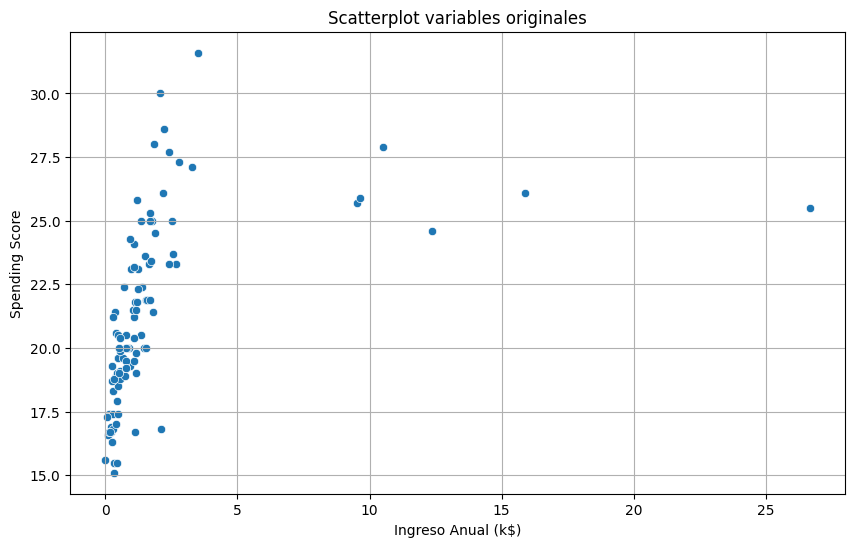

In [4]:
# visualizar datos
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 6))
sns.scatterplot(
    data=df,
    x="densidad_anuncios",
    y="precio_m2_vivienda"
)

plt.title("Scatterplot variables originales")
plt.xlabel("Ingreso Anual (k$)")
plt.ylabel("Spending Score")
plt.grid(True)
plt.show()

In [5]:
scaler = StandardScaler()

X_scaled=scaler.fit_transform(X)

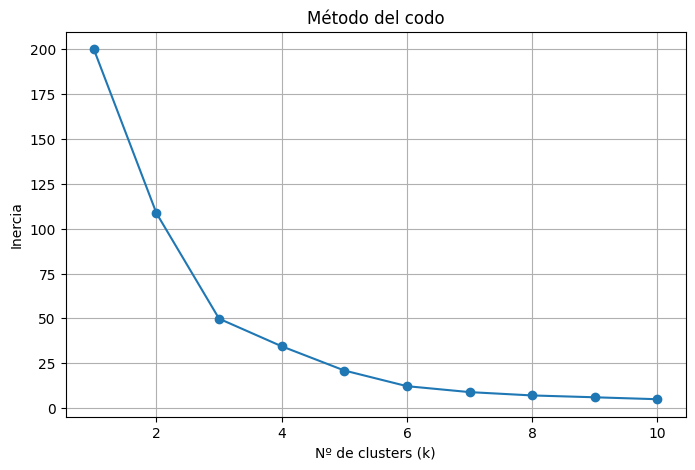

In [6]:
#METODO DEL CODO

from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

inertia = []
K_range = range(1, 11)

for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X_scaled)
    inertia.append(kmeans.inertia_)

plt.figure(figsize=(8, 5))
plt.plot(K_range, inertia, marker='o')
plt.title("Método del codo")
plt.xlabel("Nº de clusters (k)")
plt.ylabel("Inercia")
plt.grid(True)
plt.show()

In [20]:
kmeans = KMeans(n_clusters=3,random_state=42)
clusters=kmeans.fit_predict(X_scaled)
df["Cluster"]=clusters

print("\n CENTROIDES ESCALADOS")
print(kmeans.cluster_centers_)


 CENTROIDES ESCALADOS
[[ 1.09640188  0.00458847]
 [-0.61279628 -0.32437919]
 [ 1.3393506   3.49193031]]


In [21]:
# SILHOUETTE SCORE

score=silhouette_score(X_scaled,clusters)
print("Silhouette Score:",score)

Silhouette Score: 0.5661682633213088


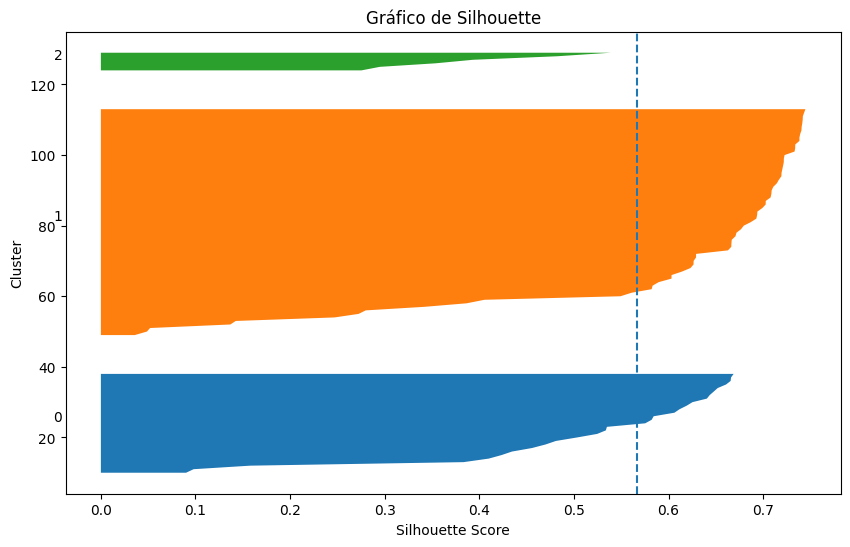

In [22]:
from sklearn.metrics import silhouette_samples, silhouette_score
import matplotlib.pyplot as plt
import numpy as np

# Calcular el silhouette de cada observación
silhouette_values = silhouette_samples(X_scaled, clusters)

plt.figure(figsize=(10, 6))

y_lower = 10

for i in range(3): #los 5 cluster
    valores_cluster = silhouette_values[clusters == i]
    valores_cluster.sort() #ordena puntuaciones

    y_upper = y_lower + len(valores_cluster)

    plt.fill_betweenx( 
        np.arange(y_lower, y_upper),
        0,
        valores_cluster
    ) #relleno del cluster

    plt.text(-0.05, (y_lower + y_upper) / 2, str(i))

    y_lower = y_upper + 10

# Línea del promedio
score = silhouette_score(X_scaled, clusters)
plt.axvline(x=score, linestyle="--")

plt.title("Gráfico de Silhouette")
plt.xlabel("Silhouette Score")
plt.ylabel("Cluster")

plt.show()

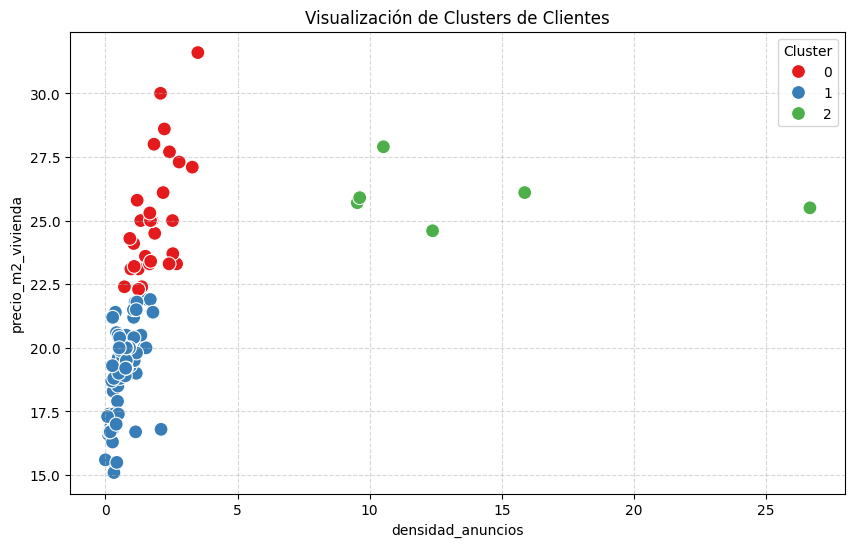

In [24]:
# VISUALIZACION FINAL DE CLUSTERS
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 6))
sns.scatterplot(
    data=df,
    x='densidad_anuncios',
    y='precio_m2_vivienda',
    hue='Cluster',
    palette='Set1',
    s=100
)

plt.title("Visualización de Clusters de Clientes")
plt.grid(True, linestyle="--", alpha=0.5)
plt.show()



In [26]:
df.groupby("Cluster")[["densidad_anuncios","precio_m2_vivienda"]].mean()

,densidad_anuncios,precio_m2_vivienda
Cluster,,
0,1.849372,25.086207
1,0.694136,19.009231
2,14.095870,25.950000


In [27]:
# CELDA 4 - Nombrar los grupos y describirlos
# ============================================
# 1. Diccionario número -> nombre (según TU tabla de medias)
#    Con random_state=42 los números no cambian entre ejecuciones
nombres = {
    2: "Centro turístico",
    0: "Residencial caro",
    1: "Residencial asequible"
}
df["tipo_cluster"] = df["Cluster"].map(nombres)

In [28]:
# Copiar al portapapeles ordenado como en Excel
# id_barrio es texto: se ordena como número para que salga igual que en Excel
(df.assign(orden=df["id_barrio"].astype(int))
   .sort_values("orden")
   [["id_barrio", "nombre_barrio", "Cluster", "tipo_cluster"]]
   .to_clipboard(index=False, decimal=","))
print("Copiado. Ve a Excel y pulsa Ctrl + V")

Copiado. Ve a Excel y pulsa Ctrl + V
